
# Retinal DR Online Smoke Test v0.1

**Project:** Cross-Modal Diagnostic Observability  
**Purpose:** browser-only data provenance, label, patient-identity, acquisition-profile and perturbation checks before any large download or model training.

This notebook is deliberately **not** a classifier-training notebook. Sections 00–04 require no model training and are intended to answer:

1. Are the dataset version and files traceable?
2. Can labels be matched to images?
3. Can a patient-safe split be defined?
4. What acquisition and image-quality differences are visible?
5. Are the proposed perturbations interpretable enough for later diagnostic-evidence experiments?

## Formal-use rule

- Formal experiments must use an official, traceable dataset version.
- Third-party resized, cropped, augmented, relabelled or merged copies may be used only to test notebook plumbing.
- Do not mix regular fundus and ultra-widefield subsets unless the study explicitly treats them as separate domains.
- Do not reveal or use a sealed blind target's diagnostic labels during target-support estimation.



## 00 — Environment and run manifest

Choose **Runtime → Run all** in Google Colab.  
No MATLAB or local Python installation is needed.


In [1]:

#@title 00.1 Runtime information
import os, sys, json, platform, hashlib, re, math, statistics
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance, ImageOps

print("Python:", sys.version)
print("Platform:", platform.platform())
print("UTC time:", datetime.now(timezone.utc).isoformat())

RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
print("RUN_ID:", RUN_ID)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
UTC time: 2026-07-18T12:27:37.589431+00:00
RUN_ID: 20260718T122737Z



### 00.2 Select the data source

Three supported routes:

- **Google Drive:** mount your Drive and point `DATASET_ROOT` to an official archive extracted there.
- **Colab upload:** upload a small ZIP/CSV for a temporary smoke test.
- **Kaggle Notebook:** copy this notebook to Kaggle and set `DATASET_ROOT` to `/kaggle/input/<dataset-folder>`.

For the first run, use a **small official dataset or a small official subset**. IDRiD is the preferred first mechanism dataset; DeepDRiD is preferred for patient and image-quality structure.


In [13]:

#@title 00.2 Configuration
# Change only these fields for the first run.

DATASET_NAME = "IDRiD"  #@param {type:"string"}
DATASET_VERSION = "Official IEEE DataPort release, accessed 2026-07-18"      #@param {type:"string"}
OFFICIAL_SOURCE_URL = "https://doi.org/10.21227/H25W98"            #@param {type:"string"}

# Example Colab Drive path:
# DATASET_ROOT = "/content/drive/MyDrive/<your-path>"
# Example Kaggle path:
# DATASET_ROOT = "/kaggle/input/<dataset-folder>"
DATASET_ROOT = "/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/02_Dataset_Map/IDRiD_Official_Raw/B. Disease Grading/1. Original Images/a. Training Set"  #@param {type:"string"}

# Leave blank to auto-discover CSV files.
LABEL_CSV = "/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/02_Dataset_Map/IDRiD_Official_Raw/B. Disease Grading/2. Groundtruths/a. IDRiD_Disease Grading_Training Labels.csv"                      #@param {type:"string"}

# Set after viewing the CSV columns. Leave blank for discovery-only runs.
IMAGE_ID_COLUMN = "Image name"                #@param {type:"string"}
LABEL_COLUMN = "Retinopathy grade"                   #@param {type:"string"}

# Common extensions.
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"]

# Optional regular expression containing one capture group for patient ID.
# Examples:
# EyePACS filenames: r"^(\d+)_(left|right)$"
# Use blank if unknown.
PATIENT_ID_REGEX = ""               #@param {type:"string"}

MAX_PROFILE_IMAGES = 500
RANDOM_SEED = 20260718
rng = np.random.default_rng(RANDOM_SEED)

root = Path(DATASET_ROOT)
root.mkdir(parents=True, exist_ok=True)

manifest = {
    "run_id": RUN_ID,
    "dataset_name": DATASET_NAME,
    "declared_version": DATASET_VERSION,
    "official_source_url": OFFICIAL_SOURCE_URL,
    "dataset_root": str(root),
    "label_csv": LABEL_CSV,
    "image_id_column": IMAGE_ID_COLUMN,
    "label_column": LABEL_COLUMN,
    "patient_id_regex": PATIENT_ID_REGEX,
    "random_seed": RANDOM_SEED,
}
print(json.dumps(manifest, indent=2))


{
  "run_id": "20260718T122737Z",
  "dataset_name": "IDRiD",
  "declared_version": "Official IEEE DataPort release, accessed 2026-07-18",
  "official_source_url": "https://doi.org/10.21227/H25W98",
  "dataset_root": "/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/02_Dataset_Map/IDRiD_Official_Raw/B. Disease Grading/1. Original Images/a. Training Set",
  "label_csv": "/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/02_Dataset_Map/IDRiD_Official_Raw/B. Disease Grading/2. Groundtruths/a. IDRiD_Disease Grading_Training Labels.csv",
  "image_id_column": "Image name",
  "label_column": "Retinopathy grade",
  "patient_id_regex": "",
  "random_seed": 20260718
}



### 00.3 Optional: mount Google Drive

Run this cell only in Colab when data or outputs are in Google Drive.


In [3]:

#@title 00.3 Mount Google Drive (optional)
try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive mounted.")
except Exception as exc:
    print("Not running in Colab or Drive mount was skipped:", exc)


Mounted at /content/drive
Google Drive mounted.



## 01 — File and label discovery

This section does not train a model. It records:

- file count and extensions,
- CSV names and columns,
- missing or unmatched images,
- a reproducible file manifest.


In [14]:

#@title 01.1 Discover image and CSV files
if not root.exists():
    raise FileNotFoundError(f"DATASET_ROOT does not exist: {root}")

all_files = [p for p in root.rglob("*") if p.is_file()]
image_files = [p for p in all_files if p.suffix.lower() in IMAGE_EXTENSIONS]
csv_files = [p for p in all_files if p.suffix.lower() == ".csv"]

print("All files:", len(all_files))
print("Image files:", len(image_files))
print("CSV files:", len(csv_files))

ext_counts = pd.Series([p.suffix.lower() for p in all_files]).value_counts()
display(ext_counts.to_frame("count").head(30))

print("\nCSV candidates:")
for p in csv_files:
    print(" -", p)


All files: 413
Image files: 413
CSV files: 0


,count
.jpg,413



CSV candidates:


In [7]:

#@title 01.2 Load label CSV or inspect candidates
label_df = None
label_path = None

if LABEL_CSV:
    label_path = Path(LABEL_CSV)
    if not label_path.is_absolute():
        label_path = root / label_path
elif len(csv_files) == 1:
    label_path = csv_files[0]

if label_path is not None and label_path.exists():
    label_df = pd.read_csv(label_path)
    print("Loaded:", label_path)
    print("Shape:", label_df.shape)
    print("Columns:", list(label_df.columns))
    display(label_df.head())
else:
    print("No label CSV selected. Set LABEL_CSV after inspecting the candidates.")


Loaded: /content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/02_Dataset_Map/IDRiD_Official_Raw/B. Disease Grading/2. Groundtruths/a. IDRiD_Disease Grading_Training Labels.csv
Shape: (413, 12)
Columns: ['Image name', 'Retinopathy grade', 'Risk of macular edema ', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']


,Image name,Retinopathy grade,Risk of macular edema,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,IDRiD_001,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IDRiD_002,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IDRiD_003,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IDRiD_004,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IDRiD_005,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:

#@title 01.3 Create a file manifest with SHA-256 for small metadata files
def sha256_file(path, chunk_size=1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

manifest_rows = []
for p in all_files:
    rel = str(p.relative_to(root))
    row = {
        "relative_path": rel,
        "extension": p.suffix.lower(),
        "size_bytes": p.stat().st_size,
        "sha256": "",
    }
    # Hash metadata and small files immediately; large image hashing can be done later.
    if p.suffix.lower() in [".csv", ".json", ".txt", ".md"] or p.stat().st_size < 5_000_000:
        try:
            row["sha256"] = sha256_file(p)
        except Exception as exc:
            row["sha256"] = f"ERROR: {exc}"
    manifest_rows.append(row)

file_manifest_df = pd.DataFrame(manifest_rows)
display(file_manifest_df.head())
print("Manifest rows:", len(file_manifest_df))


,relative_path,extension,size_bytes,sha256
0,IDRiD_132.jpg,.jpg,772640,e589f71d949b7aeb40ff10502c78d3288be90fc846be3f...
1,IDRiD_008.jpg,.jpg,429864,ff153323008a0d0392df7b4841b699a4e5de53e6b32322...
2,IDRiD_007.jpg,.jpg,387660,d19bc129f7032a353796c123b9abcc059128f109fbb9ec...
3,IDRiD_001.jpg,.jpg,409680,8cbb3482b62a7b4c8a7353a4f25ecf5df80b6f39714f35...
4,IDRiD_010.jpg,.jpg,383121,5510120b5ad420b7214e46fd5d21f1b5be7f36ee2b7aea...


Manifest rows: 413



## 02 — Patient, eye and duplicate audit

A random image split is unsafe when the same patient contributes both eyes or multiple views.  
This section attempts to identify patient structure before modelling.


In [15]:

#@title 02.1 Parse image stems and optional patient IDs
image_index_df = pd.DataFrame({
    "path": [str(p) for p in image_files],
    "filename": [p.name for p in image_files],
    "stem": [p.stem for p in image_files],
    "extension": [p.suffix.lower() for p in image_files],
    "size_bytes": [p.stat().st_size for p in image_files],
})

def parse_patient_id(stem):
    if not PATIENT_ID_REGEX:
        return None
    m = re.search(PATIENT_ID_REGEX, stem)
    return m.group(1) if m else None

image_index_df["patient_id"] = image_index_df["stem"].map(parse_patient_id)

display(image_index_df.head())
print("Images:", len(image_index_df))
if PATIENT_ID_REGEX:
    print("Parsed patient IDs:", image_index_df["patient_id"].notna().sum())
    display(image_index_df.groupby("patient_id").size().describe())
else:
    print("PATIENT_ID_REGEX is blank. Inspect filenames and define it only when the dataset convention is documented.")


,path,filename,stem,extension,size_bytes,patient_id
0,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,IDRiD_132.jpg,IDRiD_132,.jpg,772640,None
1,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,IDRiD_008.jpg,IDRiD_008,.jpg,429864,None
2,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,IDRiD_007.jpg,IDRiD_007,.jpg,387660,None
3,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,IDRiD_001.jpg,IDRiD_001,.jpg,409680,None
4,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,IDRiD_010.jpg,IDRiD_010,.jpg,383121,None


Images: 413
PATIENT_ID_REGEX is blank. Inspect filenames and define it only when the dataset convention is documented.


In [17]:

#@title 02.2 Exact duplicate check by file hash on a sample or the full small dataset
# For a small dataset this can hash all images. For a large dataset it samples up to 2,000 files.
hash_sample = image_files if len(image_files) <= 2000 else list(rng.choice(image_files, size=2000, replace=False))
hash_rows = []
for p in hash_sample:
    try:
        hash_rows.append({"path": str(p), "sha256": sha256_file(p)})
    except Exception as exc:
        hash_rows.append({"path": str(p), "sha256": f"ERROR: {exc}"})

hash_df = pd.DataFrame(hash_rows)
duplicate_hashes = hash_df[hash_df.duplicated("sha256", keep=False) & ~hash_df["sha256"].str.startswith("ERROR")]
print("Hashed files:", len(hash_df))
print("Exact duplicate files found:", len(duplicate_hashes))
display(duplicate_hashes.sort_values("sha256").head(30))


Hashed files: 413
Exact duplicate files found: 0


,path,sha256



## 03 — Basic acquisition and image profile

These metrics are **baselines**, not diagnostic-observability measures.  
They help detect simple explanations such as resolution, black borders, exposure and blur.


In [18]:

#@title 03.1 Image metrics
def load_rgb(path):
    with Image.open(path) as im:
        return im.convert("RGB")

def grayscale_array(im):
    return np.asarray(im.convert("L"), dtype=np.float32)

def laplacian_variance(gray):
    # NumPy implementation to avoid requiring OpenCV.
    center = -4 * gray[1:-1, 1:-1]
    neigh = (
        gray[:-2, 1:-1] + gray[2:, 1:-1] +
        gray[1:-1, :-2] + gray[1:-1, 2:]
    )
    lap = center + neigh
    return float(np.var(lap))

def black_border_ratio(rgb, threshold=12):
    arr = np.asarray(rgb, dtype=np.float32)
    dark = np.all(arr < threshold, axis=2)
    return float(dark.mean())

def image_metrics(path):
    im = load_rgb(path)
    arr = np.asarray(im, dtype=np.float32)
    gray = grayscale_array(im)
    return {
        "path": str(path),
        "width": im.width,
        "height": im.height,
        "aspect_ratio": im.width / max(im.height, 1),
        "file_size_bytes": Path(path).stat().st_size,
        "gray_mean": float(gray.mean()),
        "gray_std": float(gray.std()),
        "black_border_ratio": black_border_ratio(im),
        "laplacian_variance": laplacian_variance(gray),
        "red_mean": float(arr[:,:,0].mean()),
        "green_mean": float(arr[:,:,1].mean()),
        "blue_mean": float(arr[:,:,2].mean()),
    }

if not image_files:
    raise RuntimeError("No images discovered. Check DATASET_ROOT and IMAGE_EXTENSIONS.")

profile_files = image_files if len(image_files) <= MAX_PROFILE_IMAGES else list(
    rng.choice(image_files, size=MAX_PROFILE_IMAGES, replace=False)
)

profile_rows = []
for i, p in enumerate(profile_files, 1):
    try:
        profile_rows.append(image_metrics(p))
    except Exception as exc:
        profile_rows.append({"path": str(p), "error": str(exc)})

profile_df = pd.DataFrame(profile_rows)
print("Profiled:", len(profile_df))
display(profile_df.head())
display(profile_df.describe(include="all").T)


Profiled: 413


,path,width,height,aspect_ratio,file_size_bytes,gray_mean,gray_std,black_border_ratio,laplacian_variance,red_mean,green_mean,blue_mean
0,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,4288,2848,1.505618,772640,70.068001,49.775131,0.309039,10.391648,120.433022,55.296925,13.641157
1,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,4288,2848,1.505618,429864,55.880482,40.568172,0.307552,28.258329,89.357368,45.281574,22.805910
2,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,4288,2848,1.505618,387660,53.565292,39.752155,0.307424,25.838615,86.618088,42.412533,24.349771
3,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,4288,2848,1.505618,409680,72.014481,48.711796,0.291370,24.421791,121.098648,59.546307,8.061995
4,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,4288,2848,1.505618,383121,69.640800,48.940243,0.300025,20.355185,123.718857,55.083595,3.449320


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
path,413,413,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
width,413.0,NaN,NaN,NaN,4288.0,0.0,4288.0,4288.0,4288.0,4288.0,4288.0
height,413.0,NaN,NaN,NaN,2848.0,0.0,2848.0,2848.0,2848.0,2848.0,2848.0
aspect_ratio,413.0,NaN,NaN,NaN,1.505618,0.0,1.505618,1.505618,1.505618,1.505618,1.505618
file_size_bytes,413.0,NaN,NaN,NaN,402065.503632,67587.891453,240444.0,382215.0,398499.0,421389.0,811059.0
gray_mean,413.0,NaN,NaN,NaN,66.733233,13.680163,24.747307,58.416149,67.876961,76.57119,96.578903
gray_std,413.0,NaN,NaN,NaN,46.959437,8.728684,20.183231,41.834892,47.777985,53.284527,67.228821
black_border_ratio,413.0,NaN,NaN,NaN,0.301426,0.015544,0.163085,0.301008,0.307562,0.30857,0.309948
laplacian_variance,413.0,NaN,NaN,NaN,22.495837,5.569741,4.402032,20.349194,23.272852,25.778585,33.673626
red_mean,413.0,NaN,NaN,NaN,110.815141,19.452757,44.298714,99.821381,112.494553,123.442192,153.155136


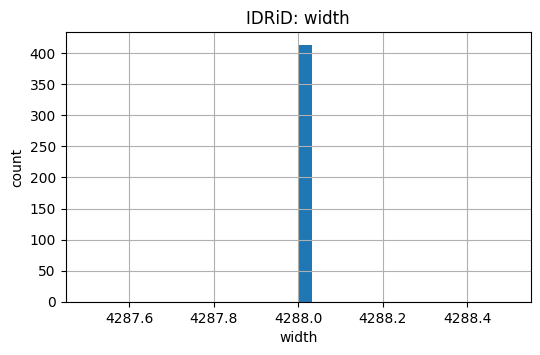

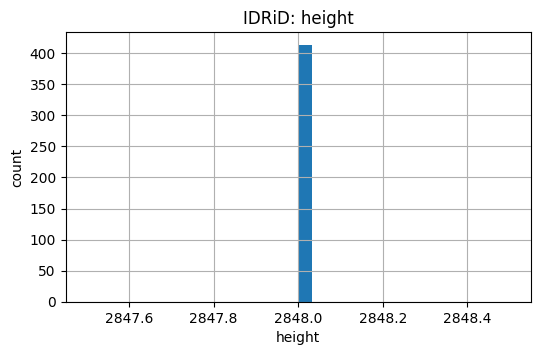

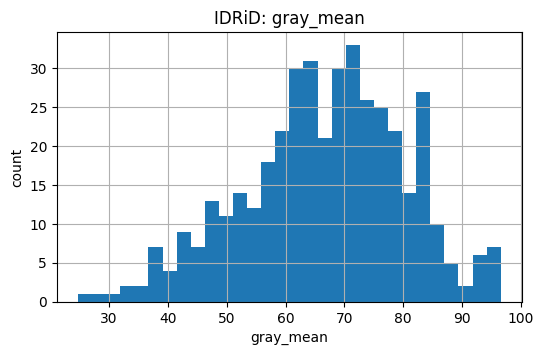

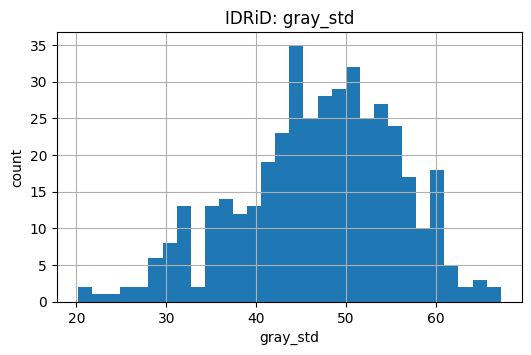

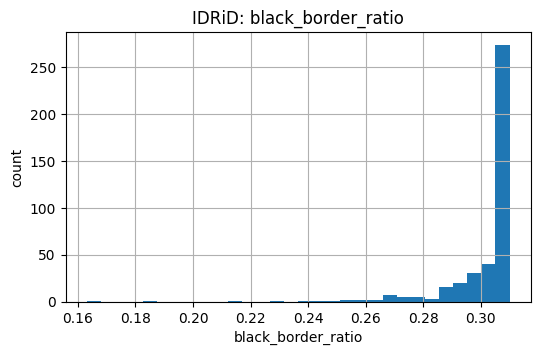

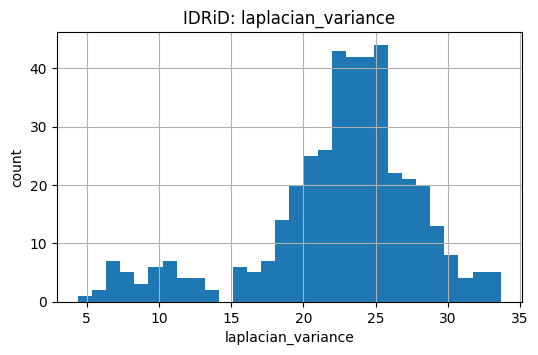

In [19]:

#@title 03.2 Visual summaries
metric_cols = [
    "width","height","gray_mean","gray_std",
    "black_border_ratio","laplacian_variance"
]
available = [c for c in metric_cols if c in profile_df.columns]

for c in available:
    plt.figure(figsize=(6, 3.5))
    profile_df[c].dropna().hist(bins=30)
    plt.title(f"{DATASET_NAME}: {c}")
    plt.xlabel(c)
    plt.ylabel("count")
    plt.show()


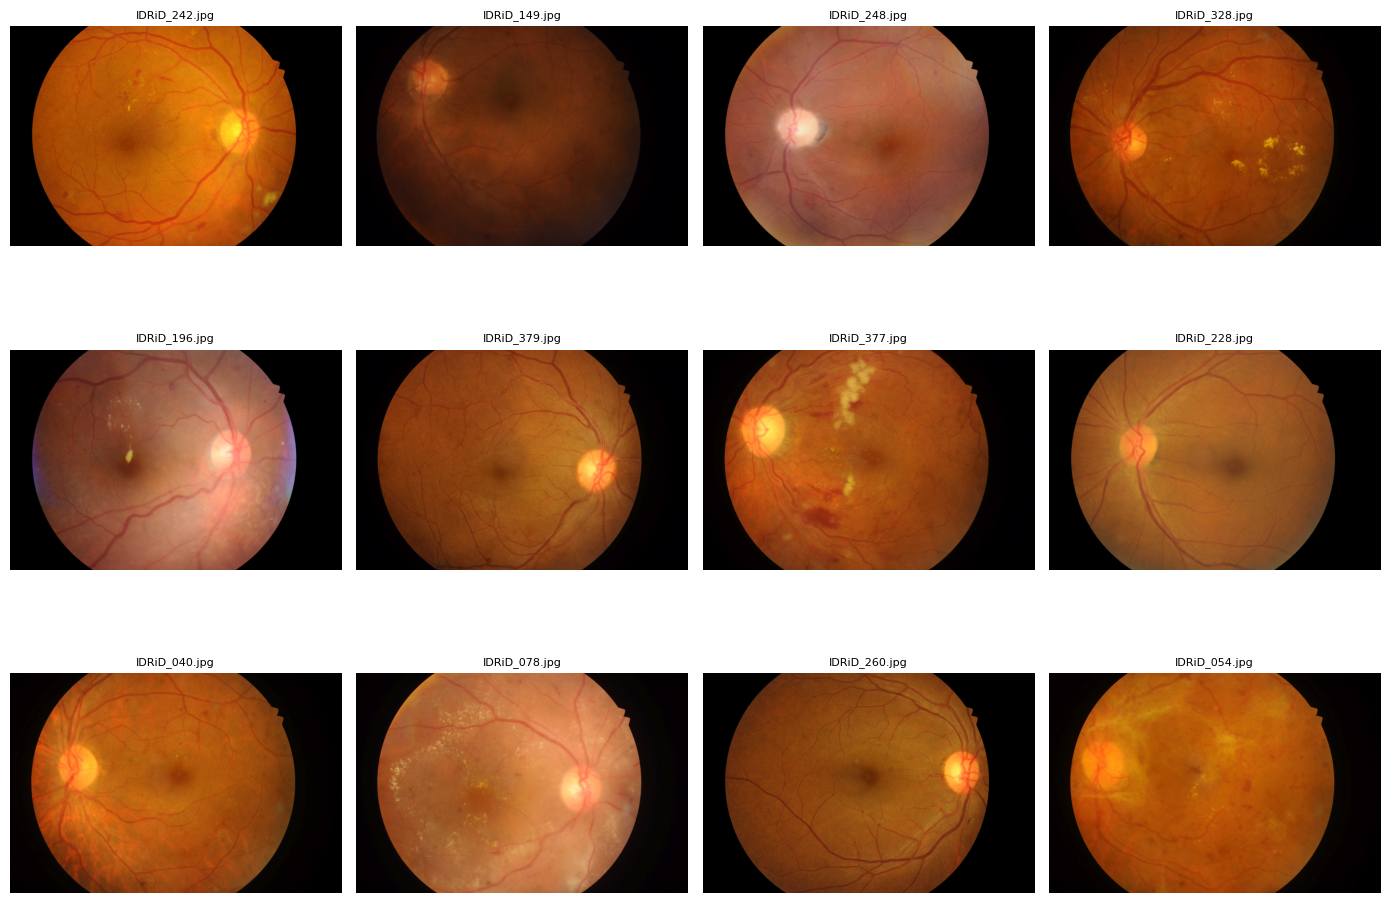

In [20]:

#@title 03.3 Random image gallery
n_show = min(12, len(image_files))
show_files = list(rng.choice(image_files, size=n_show, replace=False))

cols = 4
rows = math.ceil(n_show / cols)
plt.figure(figsize=(14, 3.5 * rows))
for i, p in enumerate(show_files, 1):
    im = load_rgb(p)
    ax = plt.subplot(rows, cols, i)
    ax.imshow(im)
    ax.set_title(p.name[:45], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()



## 04 — Perturbation preview

The purpose is to verify that each proposed information-removal operation is interpretable.  
Do not proceed to performance-response experiments until these operations have been reviewed visually.


In [21]:

#@title 04.1 Perturbation functions
def resize_roundtrip(im, scale=0.25):
    w, h = im.size
    small = im.resize((max(1, int(w*scale)), max(1, int(h*scale))), Image.Resampling.BILINEAR)
    return small.resize((w, h), Image.Resampling.BILINEAR)

def gaussian_blur(im, radius=4):
    return im.filter(ImageFilter.GaussianBlur(radius=radius))

def grayscale_rgb(im):
    return ImageOps.grayscale(im).convert("RGB")

def contrast_change(im, factor=0.5):
    return ImageEnhance.Contrast(im).enhance(factor)

def mask_center(im, radius_fraction=0.25):
    arr = np.asarray(im).copy()
    h, w = arr.shape[:2]
    yy, xx = np.ogrid[:h, :w]
    r = radius_fraction * min(h, w)
    mask = (xx - w/2)**2 + (yy - h/2)**2 <= r**2
    arr[mask] = 0
    return Image.fromarray(arr)

def mask_outer(im, radius_fraction=0.42):
    arr = np.asarray(im).copy()
    h, w = arr.shape[:2]
    yy, xx = np.ogrid[:h, :w]
    r = radius_fraction * min(h, w)
    keep = (xx - w/2)**2 + (yy - h/2)**2 <= r**2
    arr[~keep] = 0
    return Image.fromarray(arr)

perturbations = {
    "original": lambda x: x,
    "downsample_25%": lambda x: resize_roundtrip(x, 0.25),
    "blur_r4": lambda x: gaussian_blur(x, 4),
    "grayscale": grayscale_rgb,
    "contrast_0.5": lambda x: contrast_change(x, 0.5),
    "mask_center": lambda x: mask_center(x, 0.25),
    "mask_outer": lambda x: mask_outer(x, 0.42),
}


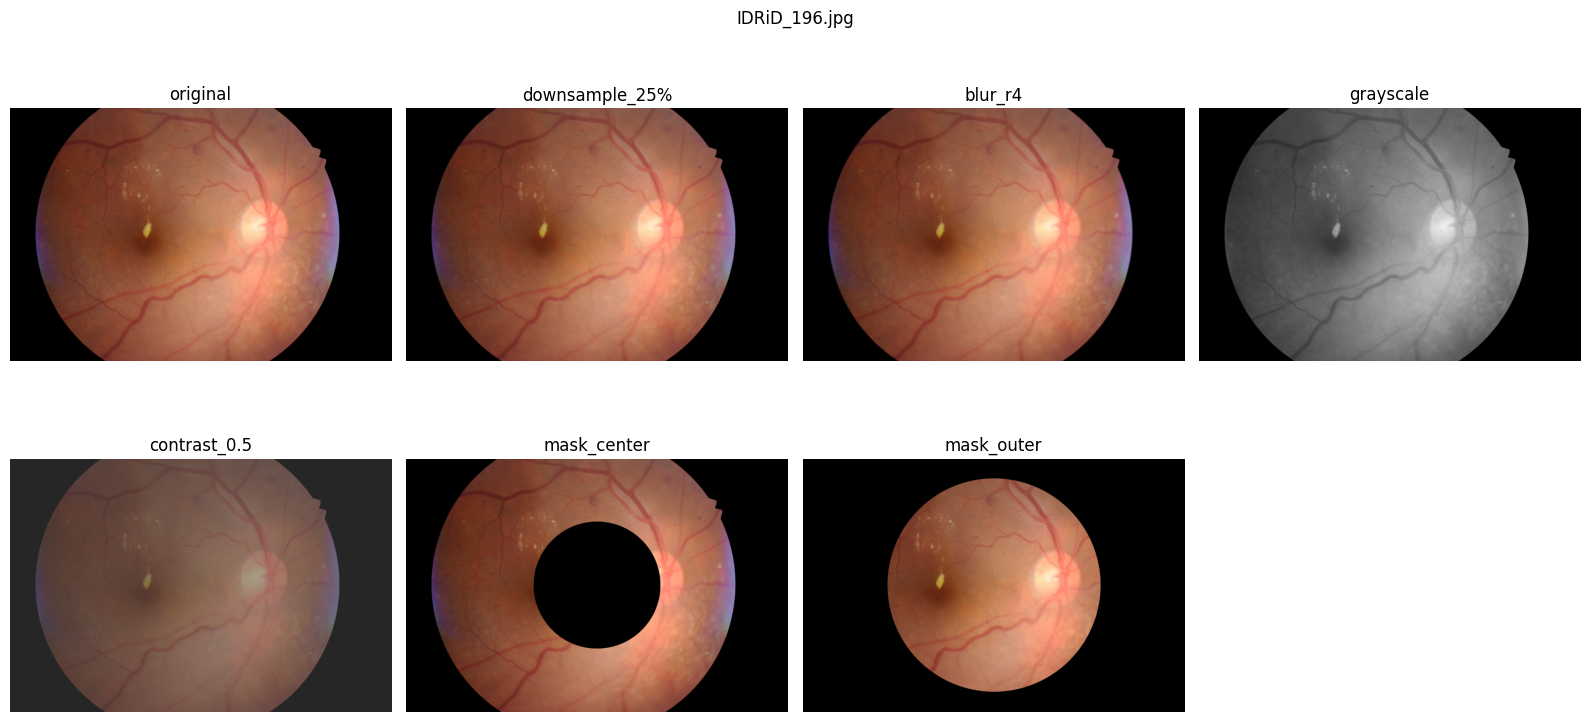

In [22]:

#@title 04.2 Preview perturbations on one random image
sample_path = rng.choice(image_files)
sample_im = load_rgb(sample_path)

plt.figure(figsize=(16, 8))
for i, (name, fn) in enumerate(perturbations.items(), 1):
    ax = plt.subplot(2, 4, i)
    ax.imshow(fn(sample_im))
    ax.set_title(name)
    ax.axis("off")
plt.suptitle(sample_path.name)
plt.tight_layout()
plt.show()



## 05 — Label schema and development-only sanity checks

Run this section only on **development datasets**.  
Do not use a sealed blind target's diagnostic labels here.

The first sanity question is not whether a classifier achieves high AUROC. It is whether ordinary quality variables already explain most of the label or dataset difference.


In [16]:

#@title 05.1 Match labels to images (configure IMAGE_ID_COLUMN and LABEL_COLUMN first)
if label_df is None:
    print("No label dataframe is loaded.")
elif not IMAGE_ID_COLUMN or not LABEL_COLUMN:
    print("Set IMAGE_ID_COLUMN and LABEL_COLUMN in section 00.2, then rerun.")
elif IMAGE_ID_COLUMN not in label_df.columns or LABEL_COLUMN not in label_df.columns:
    print("Configured columns are not present:", IMAGE_ID_COLUMN, LABEL_COLUMN)
else:
    labels = label_df[[IMAGE_ID_COLUMN, LABEL_COLUMN]].copy()
    labels["image_key"] = labels[IMAGE_ID_COLUMN].astype(str).map(lambda s: Path(s).stem)
    image_index_df["image_key"] = image_index_df["stem"].astype(str)
    matched_df = image_index_df.merge(labels[["image_key", LABEL_COLUMN]], on="image_key", how="left")
    print("Matched labels:", matched_df[LABEL_COLUMN].notna().sum(), "/", len(matched_df))
    display(matched_df.head())
    display(matched_df[LABEL_COLUMN].value_counts(dropna=False).sort_index().to_frame("count"))


Matched labels: 413 / 413


,path,filename,stem,extension,size_bytes,patient_id,image_key,Retinopathy grade
0,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,IDRiD_132.jpg,IDRiD_132,.jpg,772640,None,IDRiD_132,2
1,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,IDRiD_008.jpg,IDRiD_008,.jpg,429864,None,IDRiD_008,4
2,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,IDRiD_007.jpg,IDRiD_007,.jpg,387660,None,IDRiD_007,4
3,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,IDRiD_001.jpg,IDRiD_001,.jpg,409680,None,IDRiD_001,3
4,/content/drive/MyDrive/Cross-Modal_Diagnostic_...,IDRiD_010.jpg,IDRiD_010,.jpg,383121,None,IDRiD_010,4


,count
Retinopathy grade,
0,134
1,20
2,136
3,74
4,49



## 06 — Save the smoke-test outputs

Saving creates:

- `run_manifest.json`
- `file_manifest.csv`
- `image_profile.csv`
- optional figures added manually through the Colab interface

For now, save to the runtime or a mounted Google Drive folder. The raw images do not need to be copied into Drive.


In [24]:

#@title 06.1 Save outputs
OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/"
    "06_Data_Records/IDRiD/Smoke_Test_v0.1"
) / RUN_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(OUTPUT_DIR / "run_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

file_manifest_df.to_csv(OUTPUT_DIR / "file_manifest.csv", index=False)
image_index_df.to_csv(OUTPUT_DIR / "image_index.csv", index=False)
profile_df.to_csv(OUTPUT_DIR / "image_profile.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR)
print(list(OUTPUT_DIR.iterdir()))


Saved outputs to: /content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/IDRiD/Smoke_Test_v0.1/20260718T122737Z
[PosixPath('/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/IDRiD/Smoke_Test_v0.1/20260718T122737Z/run_manifest.json'), PosixPath('/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/IDRiD/Smoke_Test_v0.1/20260718T122737Z/file_manifest.csv'), PosixPath('/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/IDRiD/Smoke_Test_v0.1/20260718T122737Z/image_index.csv'), PosixPath('/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/IDRiD/Smoke_Test_v0.1/20260718T122737Z/image_profile.csv')]



# Stop rule after the first run

Do **not** proceed to large training merely because the notebook runs.

Proceed only when:

- the official dataset version and licence are recorded,
- labels match images,
- a patient-safe split is possible,
- the proposed perturbations are visually defensible,
- and the basic acquisition profile is reproducible.

The next notebook version will add frozen-encoder, MMD/OT/prototype and perturbation-consistency baselines only after the dataset map is locked.
